MAKEMORE_II: CHARACTER LANGUAGE MODEL

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline 

In [2]:
words = open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
block_size = 3
X, Y = [],[]
for w in words[:5]:
    print(w)
    context = [0]*block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)  

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [6]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

Lookup Table C: (Input layer)

In [7]:
C = torch.randn((27, 2))

In [8]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

First Hidden Layer: Tanh

In [9]:
W1 = torch.randn((6,100)) #6 inputs and 100 neurons
b1 = torch.randn(100) #each neuron has a bias

In [10]:
torch.cat([emb[:,0,:], emb[:,1,:],emb[:,2,:]],1).shape #cat concatenates the first 3 embeddings

torch.Size([32, 6])

In [11]:
torch.cat(torch.unbind(emb, 1),1).shape #unbind helps us do the same thing as previous line, but without having to call emb slicing again and again.

torch.Size([32, 6])

In [12]:
emb.view(32,6).shape #View helps us view the same tensor in different dimensions. Therefore this is the same as the previous line, but more efficient as cat creates another memory space, view doesnt

torch.Size([32, 6])

In [13]:
#Therefore
h = torch.tanh(emb.view(-1,6) @ W1 + b1) #tanh layer

In [14]:
h

tensor([[ 0.8724, -0.9957,  0.3294,  ..., -0.2988, -0.9990, -0.9720],
        [ 0.9926, -0.9547,  0.9897,  ...,  0.4186, -0.9962, -0.9935],
        [-0.1835, -0.9963,  0.1041,  ..., -0.9519, -0.9986,  0.0919],
        ...,
        [ 0.9566,  0.9998, -0.1607,  ...,  0.4780,  0.9895, -0.0855],
        [-0.4033,  0.4246,  0.5189,  ..., -0.8347, -0.9937,  0.8286],
        [ 0.7331, -0.5865, -0.4588,  ...,  0.8153, -0.8126, -0.9790]])

In [15]:
h.shape

torch.Size([32, 100])

Final Layer: Softmax

In [16]:
W2 = torch.randn((100,27))
b2 = torch.randn(27)

In [17]:
logits = h @ W2 + b2

In [18]:
logits.shape

torch.Size([32, 27])

In [19]:
counts = logits.exp()

In [20]:
prob = counts/counts.sum(1,keepdims=True)

In [21]:
prob.shape

torch.Size([32, 27])

In [22]:
prob[0].sum()

tensor(1.)

In [23]:
loss = -prob[torch.arange(32), Y].log().mean()
loss #negative log likelihood

tensor(15.7309)

Neural Network Summary:

Getting Input Data and Labels:

In [24]:
X.shape, Y.shape

(torch.Size([32, 3]), torch.Size([32]))

Getting the parameters: C,W1,b1,W2,b2

In [25]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6,100), generator=g)
b1 = torch.randn(100,generator=g)
W2 = torch.randn((100,27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

Total number of params:

In [26]:
sum(p.nelement() for p in parameters)

3481

Hidden and output Layer: Tanh, Softmax

In [27]:
#Hidden:
emb = C[X] #(32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)

#Output:
logits = h @W2 +b2 #(32,27)
counts = logits.exp()
prob = counts/counts.sum(1,keepdims=True)
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(17.7697)

F.cross_entropy: (loss)

In [28]:
F.cross_entropy(logits,Y)

tensor(17.7697)

Advantages of F.cross_entropy: 1. Better forward pass 2. Better backward pass 3. No Tensor inconsistencies

Training loop:

In [29]:
for p in parameters:
    p.requires_grad=True

In [30]:
for _ in range(1000): 
    #NN:
    #Forward Pass: 
    emb = C[X] #(32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
    logits = h @W2 +b2 #(32,27)
    loss = F.cross_entropy(logits, Y)
    #Backward Pass:
    for p in parameters:
        p.grad = None
    loss.backward()

    #Update: 
    for p in parameters:
        p.data += -0.1 * p.grad
print(loss.item())

0.25613853335380554


Here params: 3481, and only 32 input examples THEREFORE Overfitting

Training on FULL Dataset:

In [31]:
block_size = 3
X, Y = [],[]
for w in words:
    #print(w)
    context = [0]*block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
       #print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)  

In [32]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [55]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6,100), generator=g)
b1 = torch.randn(100,generator=g)
W2 = torch.randn((100,27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [56]:
sum(p.nelement() for p in parameters)

3481

In [57]:
for p in parameters:
    p.requires_grad=True

In [36]:
for _ in range(10): 
    #NN:
    #Forward Pass: 
    emb = C[X] #(32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
    logits = h @W2 +b2 #(32,27)
    loss = F.cross_entropy(logits, Y)
    print(loss.item())
    #Backward Pass:
    for p in parameters:
        p.grad = None
    loss.backward()

    #Update: 
    for p in parameters:
        p.data += -0.1 * p.grad

19.505229949951172
17.084484100341797
15.776530265808105
14.833340644836426
14.002605438232422
13.253263473510742
12.57991886138916
11.983101844787598
11.47049331665039
11.05185604095459


MiniBatches: (take a part of the dataset to make training faster)

In [37]:
for _ in range(100): 
    #MiniBatch:
    ix = torch.randint(0, X.shape[0], (32,))
    
    #NN:
    #Forward Pass: 
    emb = C[X[ix]] #(32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
    logits = h @W2 +b2 #(32,27)
    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())

    #Backward Pass:
    for p in parameters:
        p.grad = None
    loss.backward()

    #Update: 
    for p in parameters:
        p.data += -0.1 * p.grad

11.0831937789917
15.288111686706543
11.223323822021484
10.016424179077148
9.629210472106934
9.893000602722168
11.213726997375488
9.262725830078125
8.606446266174316
7.532482147216797
8.173076629638672
11.210418701171875
6.2869110107421875
7.865896224975586
7.263705730438232
7.243673801422119
4.602025985717773
8.814879417419434
6.23808479309082
7.7872233390808105
7.090057849884033
6.3231706619262695
6.766315937042236
7.679214954376221
6.486401557922363
5.100747108459473
6.929993629455566
5.9371514320373535
6.965518474578857
7.186656951904297
7.2247161865234375
4.738834381103516
4.988438606262207
6.231078147888184
6.934656620025635
6.626786231994629
6.317651748657227
6.246964454650879
6.123528480529785
4.357283115386963
5.851505279541016
5.521720886230469
6.3968892097473145
6.095052719116211
4.487156867980957
4.037822246551514
5.425589084625244
3.6688904762268066
5.113972187042236
3.4366164207458496
4.073410987854004
4.358218193054199
4.101788520812988
5.231483459472656
4.030833244323730

Notice how with the minibatch the output came out faster

Optimization:

In [38]:
for _ in range(100): 
    #MiniBatch:
    ix = torch.randint(0, X.shape[0], (32,))
    
    #NN:
    #Forward Pass: 
    emb = C[X[ix]] #(32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
    logits = h @W2 +b2 #(32,27)
    loss = F.cross_entropy(logits, Y[ix])

    #Backward Pass:
    for p in parameters:
        p.grad = None
    loss.backward()

    #Update: 
    for p in parameters:
        p.data += -0.1 * p.grad
print(loss.item())

2.6996819972991943


Finding good learning rate

In [58]:
lre = torch.linspace(-3,0, 1000)
lrs = 10**lre
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [51]:
lri = []
lossi=[]
for i in range(1000): 
    #MiniBatch:
    ix = torch.randint(0, X.shape[0], (32,))
    
    #NN:
    #Forward Pass: 
    emb = C[X[ix]] #(32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
    logits = h @W2 +b2 #(32,27)
    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())

    #Backward Pass:
    for p in parameters:
        p.grad = None
    loss.backward()

    #Update: 
    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad

    #track stats
    lri.append(lre[i])
    lossi.append(loss.item())

#print(loss.item())

16.375904083251953
20.701467514038086
19.570539474487305
20.2949161529541
18.65578269958496
17.351659774780273
18.52086639404297
22.50452423095703
17.628803253173828
17.05206871032715
19.349849700927734
16.05059814453125
20.07390022277832
18.086105346679688
17.138471603393555
19.454578399658203
23.913360595703125
22.3164119720459
17.344867706298828
20.34989356994629
18.022592544555664
18.155715942382812
18.80891990661621
16.090330123901367
16.65450096130371
17.07547378540039
16.947391510009766
19.020477294921875
17.47088623046875
16.8471736907959
17.611845016479492
18.464929580688477
18.064516067504883
16.33299446105957
19.60407829284668
19.171323776245117
20.621788024902344
18.721582412719727
17.244876861572266
17.2850399017334
19.795310974121094
16.236003875732422
17.885723114013672
20.018857955932617
15.755105972290039
17.536291122436523
17.9550838470459
18.735244750976562
16.8212947845459
18.524066925048828
18.333675384521484
17.299562454223633
17.355985641479492
18.129314422607422

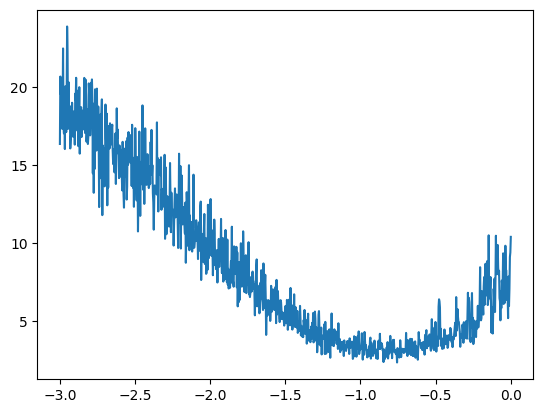

In [52]:
plt.plot(lri, lossi)

Here we can see good learning rate exponent is around -1.0, so good learning rate is 10**-1 which is 0.1

In [63]:
lri = []
lossi=[]
for i in range(10000): 
    #MiniBatch:
    ix = torch.randint(0, X.shape[0], (32,))
    
    #NN:
    #Forward Pass: 
    emb = C[X[ix]] #(32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
    logits = h @W2 +b2 #(32,27)
    loss = F.cross_entropy(logits, Y[ix])


    #Backward Pass:
    for p in parameters:
        p.grad = None
    loss.backward()

    #Update: 
    #lr = lrs[i]
    lr = 0.1 
    for p in parameters:
        p.data += -lr * p.grad

    #track stats
    #lri.append(lre[i])
    #lossi.append(loss.item())

print(loss.item())

2.699674367904663


In [64]:
emb = C[X] #(32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
logits = h @W2 +b2 #(32,27)
loss = F.cross_entropy(logits, Y)
loss

tensor(2.3994, grad_fn=<NllLossBackward0>)

Apply Learning Rate Decay: 0.1 -> 0.01

In [ ]:
lri = []
lossi=[]
for i in range(10000): 
    #MiniBatch:
    ix = torch.randint(0, X.shape[0], (32,))
    
    #NN:
    #Forward Pass: 
    emb = C[X[ix]] #(32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
    logits = h @W2 +b2 #(32,27)
    loss = F.cross_entropy(logits, Y[ix])


    #Backward Pass:
    for p in parameters:
        p.grad = None
    loss.backward()

    #Update: 
    #lr = lrs[i]
    lr = 0.01 
    for p in parameters:
        p.data += -lr * p.grad

    #track stats
    #lri.append(lre[i])
    #lossi.append(loss.item())

print(loss.item())  

2.4333581924438477


In [ ]:
emb = C[X] #(32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
logits = h @W2 +b2 #(32,27)
loss = F.cross_entropy(logits, Y)
loss        

tensor(2.3278, grad_fn=<NllLossBackward0>)

Splitting up the data into train,test,validate:

In [67]:
#train-80%, test-10%, validate-10%

def build_dataset(words):
    block_size = 3
    X, Y = [],[]
    for w in words:
        #print(w)
        context = [0]*block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
        #print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)  
    print(X.shape,Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [69]:
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [ ]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6,100), generator=g)
b1 = torch.randn(100,generator=g)
W2 = torch.randn((100,27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [84]:
sum(p.nelement() for p in parameters)

3481

In [76]:
for p in parameters:
    p.requires_grad=True

In [77]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre

In [81]:
lri = []
lossi=[]
for i in range(10000): 
    #MiniBatch:
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    #NN:
    #Forward Pass: 
    emb = C[Xtr[ix]] #(32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
    logits = h @W2 +b2 #(32,27)
    loss = F.cross_entropy(logits, Ytr[ix])


    #Backward Pass:
    for p in parameters:
        p.grad = None
    loss.backward()

    #Update: 
    #lr = lrs[i]
    lr = 0.01 
    for p in parameters:
        p.data += -lr * p.grad

    #track stats
    #lri.append(lre[i])
    #lossi.append(loss.item())

print(loss.item())  

1.9652721881866455


In [83]:
emb = C[Xtr] #(32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
logits = h @W2 +b2 #(32,27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.2909, grad_fn=<NllLossBackward0>)

In [ ]:
emb = C[Xdev] #(32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
logits = h @W2 +b2 #(32,27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.2908, grad_fn=<NllLossBackward0>)

Currently same loss for training data and validation data means , the NN is underfitting, therefore to solve we increase the number of neurons in the hidden layer from 100 -> 300

In [85]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6,300), generator=g)
b1 = torch.randn(300,generator=g)
W2 = torch.randn((300,27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [86]:
sum(p.nelement() for p in parameters)

10281

In [87]:
for p in parameters:
    p.requires_grad=True

In [88]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre

In [89]:
lri = []
lossi=[]
stepi=[]
for i in range(30000): 
    #MiniBatch:
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    #NN:
    #Forward Pass: 
    emb = C[Xtr[ix]] #(32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
    logits = h @W2 +b2 #(32,27)
    loss = F.cross_entropy(logits, Ytr[ix])


    #Backward Pass:
    for p in parameters:
        p.grad = None
    loss.backward()

    #Update: 
    #lr = lrs[i]
    lr = 0.1 
    for p in parameters:
        p.data += -lr * p.grad

    #track stats
    #lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.item())

print(loss.item())  

2.4884860515594482


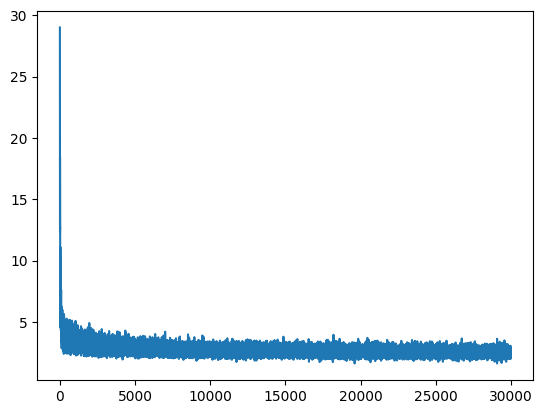

In [90]:
plt.plot(stepi,lossi)

In [91]:
emb = C[Xtr] #(32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
logits = h @W2 +b2 #(32,27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.5925, grad_fn=<NllLossBackward0>)